# Create visualization for PGS effects:
# A. PGS on behaviour
# B. PGS on brain
# C. Brain on behaviour

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

windows = True

if windows:
    workspace_path = "P:/workspaces/lg-ukbiobank/projects/"
else:
    workspace_path = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/"


fn = os.path.join(workspace_path, "CONGRADS_rest", "mediation_results_cmap_NEW.csv")
df = pd.read_csv(fn)

In [53]:
import numpy as np


def plot_bars_old(df, eff_col, std_err_col, title,sig_col, y_label, ax, color, bar_w=0.6, font="Arial"):
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Check if we need x-axis line (if any value in eff_col is negative)
    if (df[eff_col] < 0).any():
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # Create bars with alpha depending on significance
    for idx, (value, err, is_sig) in enumerate(zip(df[eff_col], df[std_err_col], df[sig_col])):
        alpha = 1.0 if is_sig else 0.6
        # Set capsize=0 to remove error bar tails
        ax.bar(idx, value, yerr=err, alpha=alpha, capsize=0, color=color, width=bar_w, linestyle="")
        if is_sig:
            ax.text(idx, value + err, '*', ha='center', va='bottom', fontname=font)
    
    # Set title and y-label with specified font
    if title:
        ax.set_title(title, fontname=font)
    ax.set_ylabel(y_label, fontname=font)
    
    # Set x-tick labels with specified font
    ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)
    
    # Apply font to y-tick labels as well
    for label in ax.get_yticklabels():
        label.set_fontname(font)

def plot_bars(df, eff_col, std_err_col, title, sig_col, y_label, ax, color, bar_w=0.6, font="Arial"):
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Check if we need x-axis line (if any value in eff_col is negative)
    if (df[eff_col] < 0).any():
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # Create bars without alpha differences (all bars have same alpha)
    if len(color) == 1:
        color = color * len(df)
    for idx, (value, err, is_sig) in enumerate(zip(df[eff_col], df[std_err_col], df[sig_col])):
        # Set capsize=0 to remove error bar tails
        ax.bar(idx, value, yerr=err, alpha=0.8, capsize=0, color=color[idx], width=bar_w, linestyle="")
    
    # Set title and y-label with specified font
    if title:
        ax.set_title(title, fontname=font, size=13)
    ax.set_ylabel(y_label, fontname=font, size=11)
    
    # Set x-tick labels with specified font
    ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)
    
    # Apply font to y-tick labels as well
    for label in ax.get_yticklabels():
        label.set_fontname(font)

In [54]:
from statsmodels.stats.multitest import multipletests
import numpy as np

a_df = df[['PGS', 'IDP', 'a_brain_effect', 'a_brain_se', 'a_brain_t', 'a_brain_pvalue']].copy()
b_df = df[['PGS', 'IDP', 'b_effect', 'b_se', 'b_t', 'b_pvalue']][:11].copy()
c_df = df[['PGS', 'IDP', 'c_effect', 'c_se', 'c_t', 'c_pvalue']].iloc[[0, 12, 24, 36, 48, 60, 72]].copy()


In [55]:
# Set significance threshold
all_ps = np.concatenate([a_df['a_brain_pvalue'], b_df['b_pvalue'], c_df['c_pvalue']])

alpha = 0.05/(8*11+7)
a_df['a_brain_bonf'] = df['a_brain_pvalue'] < alpha
a_df['a_brain_fdr'] = multipletests(all_ps, method='fdr_bh')[0][:len(a_df)]
b_df['b_bonf'] = df['b_pvalue'] < alpha
b_df['b_fdr'] = multipletests(all_ps, method='fdr_bh')[0][len(a_df):len(a_df)+len(b_df)]
c_df['c_bonf'] = df['c_pvalue'] < alpha
c_df['c_fdr'] = multipletests(all_ps, method='fdr_bh')[0][len(a_df)+len(b_df):]

a_df["a_ci_upper"] = a_df['a_brain_effect'] + 1.96 * a_df["a_brain_se"]
a_df["a_ci_lower"] = a_df['a_brain_effect'] - 1.96 * a_df["a_brain_se"]
b_df["b_ci_upper"] = b_df["b_effect"] + 1.96 * b_df["b_se"]
b_df["b_ci_lower"] = b_df["b_effect"] - 1.96 * b_df["b_se"]
c_df["c_ci_upper"] = c_df["c_effect"] + 1.96 * c_df["c_se"]
c_df["c_ci_lower"] = c_df["c_effect"] - 1.96 * c_df["c_se"]


In [56]:
a_df.to_csv(os.path.join(workspace_path, "CONGRADS_rest", "results", "pgs_brain_results_cmaps_with_significance_new.csv"))

In [57]:
b_df.to_csv(os.path.join(workspace_path, "CONGRADS_rest", "results", "brain_beh_effects_cmaps_with_significance_new.csv"))

In [58]:
c_df.to_csv(os.path.join(workspace_path, "CONGRADS_rest", "results", "pgs_beh_results_cmaps_with_significance_new.csv"))

In [59]:
a_df[a_df["a_brain_fdr"] ].head(n=50)

,PGS,IDP,a_brain_effect,a_brain_se,a_brain_t,a_brain_pvalue,a_brain_bonf,a_brain_fdr,a_ci_upper,a_ci_lower
1,READ,melodic_g1_cmap_lstg_oic_1,0.013088,0.004897,2.672555,0.007531,False,True,0.022686,0.003489
2,READ,melodic_g2_cmap_lstg_oic_1,0.016195,0.004949,3.272528,0.001067,False,True,0.025894,0.006495
3,READ,melodic_g2_cmap_lifg_oic_1,-0.012949,0.004899,-2.642950,0.008222,False,True,-0.003346,-0.022552
5,READ,melodic_g1_cmap_lstg_oic_2,-0.012863,0.004748,-2.709200,0.006747,False,True,-0.003557,-0.022169
7,READ,melodic_g2_cmap_lifg_oic_0,0.012903,0.005003,2.579250,0.009905,False,True,0.022708,0.003098
8,READ,melodic_g1_cmap_lifg_oic_2,-0.020189,0.004851,-4.161667,0.000032,True,True,-0.010681,-0.029698
13,DYSLEXIA,melodic_g2_cmap_lstg_oic_1,-0.013635,0.004897,-2.784062,0.005371,False,True,-0.004036,-0.023234
38,EA,melodic_g1_cmap_lstg_oic_2,-0.019871,0.004789,-4.148988,0.000033,True,True,-0.010484,-0.029259
41,EA,melodic_g1_cmap_lifg_oic_2,-0.020529,0.004894,-4.194464,0.000027,True,True,-0.010936,-0.030121


In [60]:

b_df[b_df["b_fdr"]].head(n=11)

,PGS,IDP,b_effect,b_se,b_t,b_pvalue,b_bonf,b_fdr,b_ci_upper,b_ci_lower
0,READ,melodic_g1_cmap_lifg_oic_1,0.021486,0.006975,3.080609,0.002068,False,True,0.035156,0.007816
1,READ,melodic_g1_cmap_lstg_oic_1,0.017590,0.006746,2.607457,0.009128,False,True,0.030811,0.004368
2,READ,melodic_g2_cmap_lstg_oic_1,0.022858,0.006706,3.408614,0.000654,False,True,0.036001,0.009714
7,READ,melodic_g2_cmap_lifg_oic_0,0.025138,0.006688,3.758590,0.000171,True,True,0.038246,0.012029
8,READ,melodic_g1_cmap_lifg_oic_2,-0.030007,0.006867,-4.370058,0.000012,True,True,-0.016549,-0.043466


In [61]:
c_df.head(n=7)

,PGS,IDP,c_effect,c_se,c_t,c_pvalue,c_bonf,c_fdr,c_ci_upper,c_ci_lower
0,READ,melodic_g1_cmap_lifg_oic_1,0.084403,0.006698,12.600312,2.847676e-36,True,True,0.097532,0.071274
12,DYSLEXIA,melodic_g1_cmap_lstg_oic_1,-0.067492,0.006698,-10.077100,7.904798e-24,True,True,-0.054364,-0.080619
24,HAND,melodic_g2_cmap_lstg_oic_1,-0.001310,0.008383,-0.156221,8.758600e-01,False,False,0.015122,-0.017741
36,EA,melodic_g2_cmap_lifg_oic_1,0.317213,0.006490,48.880839,0.000000e+00,True,True,0.329932,0.304493
48,ASD,melodic_g1_cmap_lstg_oic_0,0.055165,0.006666,8.275650,1.353145e-16,True,True,0.068231,0.042100
60,ADHD,melodic_g1_cmap_lstg_oic_2,-0.065990,0.006701,-9.847983,7.839368e-23,True,True,-0.052856,-0.079123
72,SCZ,melodic_g2_cmap_lstg_oic_2,-0.049952,0.006792,-7.354383,1.988677e-13,True,True,-0.036639,-0.063265


In [62]:
sig_idps = b_df.loc[b_df["b_fdr"], "IDP"].tolist()
mediation_combi = a_df.loc[a_df["a_brain_fdr"], ["PGS", "IDP"]].head(n=50)
mediation_combi = mediation_combi[mediation_combi["IDP"].isin(sig_idps)]
print(len(mediation_combi))

6


C:\Users\jitame\AppData\Local\Temp\ipykernel_9340\2889756599.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['IDP'] = plot_df['IDP'].map(phenos_dict)
C:\Users\jitame\AppData\Local\Temp\ipykernel_9340\1813630448.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)
C:\Users\jitame\AppData\Local\Temp\ipykernel_9340\2889756599.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/ind

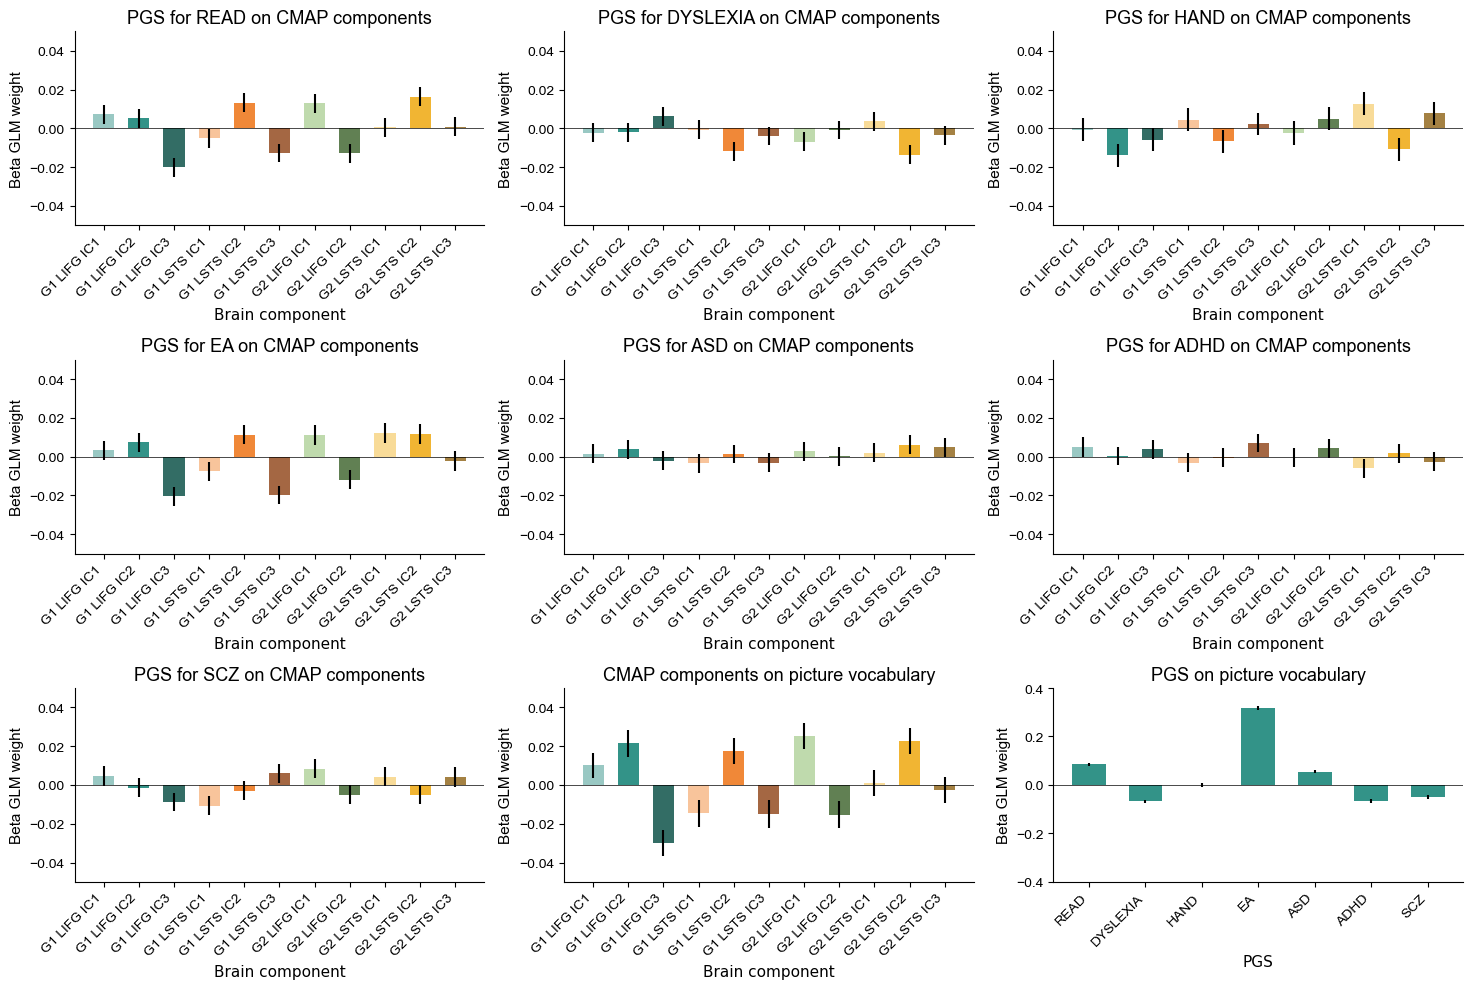

In [63]:
# plot b with plot_multiplebars
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(17.8/1.2, 12/1.2))


phenos = "melodic_g1_cmap_lifg_oic_1,melodic_g1_cmap_lstg_oic_1,melodic_g2_cmap_lstg_oic_1,melodic_g2_cmap_lifg_oic_1,melodic_g1_cmap_lstg_oic_0,melodic_g1_cmap_lstg_oic_2,melodic_g2_cmap_lstg_oic_2,melodic_g2_cmap_lifg_oic_0,melodic_g1_cmap_lifg_oic_2,melodic_g2_cmap_lstg_oic_0,melodic_g1_cmap_lifg_oic_0".split(",")
xticks = ["G1 LIFG IC1", "G1 LIFG IC2", "G1 LIFG IC3", "G1 LSTS IC1", "G1 LSTS IC2", "G1 LSTS IC3", "G2 LIFG IC1", "G2 LIFG IC2", "G2 LSTS IC1", "G2 LSTS IC2", "G2 LSTS IC3"] #"G2 LIFG IC3",
phenos_dict = {"melodic_g1_cmap_lifg_oic_1": "G1 LIFG IC2",
               "melodic_g1_cmap_lstg_oic_1": "G1 LSTS IC2",
               "melodic_g2_cmap_lstg_oic_1": "G2 LSTS IC2",
                "melodic_g2_cmap_lifg_oic_1": "G2 LIFG IC2",
                "melodic_g1_cmap_lstg_oic_0": "G1 LSTS IC1",
                "melodic_g1_cmap_lstg_oic_2": "G1 LSTS IC3",
                "melodic_g2_cmap_lstg_oic_2": "G2 LSTS IC3",
                "melodic_g2_cmap_lifg_oic_0": "G2 LIFG IC1",
                "melodic_g1_cmap_lifg_oic_2": "G1 LIFG IC3",
                "melodic_g2_cmap_lstg_oic_0": "G2 LSTS IC1",
                "melodic_g1_cmap_lifg_oic_0": "G1 LIFG IC1"
               } #
#missing pheno: "melodic_g2_cmap_lifg_oic_2": "G2 LIFG IC3"



color_list_comps = ['#80BBB4', '#00786A', '#00483F', '#F7B682', '#ED6B06', '#8E4114', "#AFD199", "#3A6128", "#F7D27F", "#EEA300", "#8E6214"]

#plot all 7 PGS analyses from a_df in separate subplots
for i, (ax, pgs) in enumerate(zip(axes.flatten()[:7], a_df['PGS'].unique())):
    plot_df = a_df[a_df['PGS'] == pgs]
    plot_df['IDP'] = plot_df['IDP'].map(phenos_dict)
    plot_df = plot_df.set_index('IDP').reindex(xticks).reset_index()

    #sort plot_df by IDP to match xticks order


    plot_bars(df=plot_df, eff_col='a_brain_effect', std_err_col='a_brain_se', sig_col='a_brain_fdr',
              title=f'PGS for {pgs} on CMAP components', y_label='Beta GLM weight', ax=ax, color=color_list_comps, bar_w=0.6)
    
    #switch of legend
    ax.set_xlabel('Brain component', fontsize=11)
    ax.set_ylabel('Beta GLM weight', fontsize=11)
    ax.set_ylim(-0.05, 0.05)

    #change font size ticks and axis labels

    ax.set_xticks(range(len(xticks)))
    ax.set_xticklabels(xticks, rotation=45, ha='right')


    for label in ax.get_xticklabels():
        label.set_fontsize(10)

    for label in ax.get_yticklabels():
        label.set_fontsize(10)

plot_df = b_df.copy(deep=True)
plot_df['IDP'] = plot_df['IDP'].map(phenos_dict)
plot_df = plot_df.set_index('IDP').reindex(xticks).reset_index()

plot_bars(df=plot_df, eff_col='b_effect', std_err_col='b_se', sig_col='b_fdr',
                    title='CMAP components on picture vocabulary', y_label='Beta GLM weight', ax=axes[2,1], color=color_list_comps, bar_w=0.6)

axes[2,1].set_xlabel('Brain component', fontsize=11)
axes[2,1].set_ylabel('Beta GLM weight', fontsize=11)
axes[2,1].set_ylim(-0.05, 0.05)

    #change font size ticks and axis labels

axes[2,1].set_xticks(range(len(xticks)))
axes[2,1].set_xticklabels(xticks, rotation=45, ha='right')


for label in axes[2,1].get_xticklabels():
    label.set_fontsize(10)

for label in axes[2,1].get_yticklabels():
    label.set_fontsize(10)

plot_bars(df=c_df, eff_col='c_effect', std_err_col='c_se', sig_col='c_fdr',
                  title='PGS on picture vocabulary', y_label='Beta GLM weight', ax=axes[2,2], color=[color_list_comps[1]], bar_w=0.6)

#switch of legend
axes[2,2].set_xlabel('PGS', fontsize=11)
axes[2,2].set_ylabel('Beta GLM weight', fontsize=11)
axes[2,2].set_ylim(-0.4, 0.4)

#change font size ticks and axis labels
xticks = c_df['PGS']
axes[2,2].set_xticks(range(len(xticks)))
axes[2,2].set_xticklabels(xticks, rotation=45, ha='right')

for label in axes[2,2].get_xticklabels():
    label.set_fontsize(10)

for label in axes[2,2].get_yticklabels():
    label.set_fontsize(10)

plt.tight_layout()
plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "results", "PGS_brain_effects_cmap_all.png"), dpi=300)
plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "results", "PGS_brain_effects_cmap_all_400.png"), dpi=300)

In [64]:
bonferoni_alpha = 0.05 / (len(mediation_combi)*4)
print(len(mediation_combi)*4)
print(bonferoni_alpha)
mediation_df = df.merge(mediation_combi, on=['PGS', 'IDP'], how='inner')[['PGS', 'IDP', 'direct_effect', 'direct_ci_lower', 'direct_ci_upper',
       'direct_pvalue', 'indirect_effect', 'indirect_ci_lower',
       'indirect_ci_upper', 'indirect_pvalue', 'total_effect',
       'total_ci_lower', 'total_ci_upper', 'total_pvalue', 'prop_mediated',
       'prop_mediated_ci_lower', 'prop_mediated_ci_upper',
       'prop_mediated_pvalue']]

all_ps = np.concatenate([mediation_df['direct_pvalue'], mediation_df['indirect_pvalue'], mediation_df['total_pvalue'], mediation_df['prop_mediated_pvalue']])
fdr_results = multipletests(all_ps, method='fdr_bh')[0]

mediation_df['direct_bonf'] = mediation_df['direct_pvalue'] < bonferoni_alpha
mediation_df['direct_fdr'] = fdr_results[:len(mediation_df)]
mediation_df['indirect_bonf'] = mediation_df['indirect_pvalue'] < bonferoni_alpha
mediation_df['indirect_fdr'] = fdr_results[len(mediation_df):2*len(mediation_df)]
mediation_df['total_bonf'] = mediation_df['total_pvalue'] < bonferoni_alpha
mediation_df['total_fdr'] = fdr_results[2*len(mediation_df):3*len(mediation_df)]
mediation_df['prop_mediated_bonf'] = mediation_df['prop_mediated_pvalue'] < bonferoni_alpha
mediation_df['prop_mediated_fdr'] = fdr_results[3*len(mediation_df):]  


mediation_df = mediation_df[ [ 'PGS', 'IDP', 'direct_effect', 'direct_ci_lower', 'direct_ci_upper', 'direct_pvalue', 'direct_bonf', 'direct_fdr',
                              'indirect_effect', 'indirect_ci_lower', 'indirect_ci_upper', 'indirect_pvalue', 'indirect_bonf', 'indirect_fdr',
                              'total_effect', 'total_ci_lower', 'total_ci_upper', 'total_pvalue', 'total_bonf', 'total_fdr',
                              'prop_mediated', 'prop_mediated_ci_lower', 'prop_mediated_ci_upper', 'prop_mediated_pvalue', 'prop_mediated_bonf', 'prop_mediated_fdr']]

mediation_df.to_csv(os.path.join(workspace_path, "CONGRADS_rest", "results", "mediation_results_with_significance_cmap.csv"))

mediation_df = mediation_df[ [ 'PGS', 'IDP', 'direct_effect', 'direct_ci_lower', 'direct_ci_upper', 'direct_pvalue', 'direct_bonf', 'direct_fdr',
                              'indirect_effect', 'indirect_ci_lower', 'indirect_ci_upper', 'indirect_pvalue', 'indirect_bonf', 'indirect_fdr',
                              'total_effect', 'total_ci_lower', 'total_ci_upper', 'total_pvalue', 'total_bonf', 'total_fdr',
                              'prop_mediated', 'prop_mediated_ci_lower', 'prop_mediated_ci_upper', 'prop_mediated_pvalue', 'prop_mediated_bonf', 'prop_mediated_fdr']]

mediation_df.head(n=50)

24
0.0020833333333333333


,PGS,IDP,direct_effect,direct_ci_lower,direct_ci_upper,direct_pvalue,direct_bonf,direct_fdr,indirect_effect,indirect_ci_lower,...,total_ci_upper,total_pvalue,total_bonf,total_fdr,prop_mediated,prop_mediated_ci_lower,prop_mediated_ci_upper,prop_mediated_pvalue,prop_mediated_bonf,prop_mediated_fdr
0,READ,melodic_g1_cmap_lstg_oic_1,0.084155,0.070680,0.097816,0.0,True,True,0.000248,6.275618e-07,...,0.098083,0.0,True,True,0.002939,0.000007,0.007235,0.050,False,False
1,READ,melodic_g2_cmap_lstg_oic_1,0.084039,0.071035,0.097576,0.0,True,True,0.000364,5.222723e-05,...,0.097960,0.0,True,True,0.004314,0.000615,0.009128,0.022,False,True
2,READ,melodic_g2_cmap_lifg_oic_0,0.083941,0.071930,0.096663,0.0,True,True,0.000462,1.146845e-04,...,0.097006,0.0,True,True,0.005472,0.001338,0.012128,0.004,False,True
3,READ,melodic_g1_cmap_lifg_oic_2,0.083585,0.070213,0.096628,0.0,True,True,0.000818,3.571788e-04,...,0.097293,0.0,True,True,0.009687,0.004125,0.017607,0.000,True,True
4,DYSLEXIA,melodic_g2_cmap_lstg_oic_1,-0.067255,-0.080079,-0.053901,0.0,True,True,-0.000237,-6.427048e-04,...,-0.054136,0.0,True,True,0.003512,-0.001004,0.009937,0.132,False,False
5,EA,melodic_g1_cmap_lifg_oic_2,0.316720,0.304927,0.327965,0.0,True,True,0.000493,1.387311e-04,...,0.328625,0.0,True,True,0.001554,0.000437,0.003026,0.000,True,True


In [65]:
mediation_df[ [ 'PGS', 'IDP', #'direct_effect', 'direct_ci_lower', 'direct_ci_upper', 'direct_pvalue', 'direct_bonf', 'direct_fdr',
                              'indirect_effect', 'indirect_ci_lower', 'indirect_ci_upper', 'indirect_pvalue', 'indirect_bonf', 'indirect_fdr',
                              'total_effect', 'total_ci_lower', 'total_ci_upper', 'total_pvalue', 'total_bonf', 'total_fdr',
                              'prop_mediated', 'prop_mediated_ci_lower', 'prop_mediated_ci_upper', 'prop_mediated_pvalue', 'prop_mediated_bonf', 'prop_mediated_fdr']].head(n=50)

,PGS,IDP,indirect_effect,indirect_ci_lower,indirect_ci_upper,indirect_pvalue,indirect_bonf,indirect_fdr,total_effect,total_ci_lower,total_ci_upper,total_pvalue,total_bonf,total_fdr,prop_mediated,prop_mediated_ci_lower,prop_mediated_ci_upper,prop_mediated_pvalue,prop_mediated_bonf,prop_mediated_fdr
0,READ,melodic_g1_cmap_lstg_oic_1,0.000248,6.275618e-07,0.000612,0.050,False,False,0.084403,0.071024,0.098083,0.0,True,True,0.002939,0.000007,0.007235,0.050,False,False
1,READ,melodic_g2_cmap_lstg_oic_1,0.000364,5.222723e-05,0.000774,0.022,False,True,0.084403,0.071454,0.097960,0.0,True,True,0.004314,0.000615,0.009128,0.022,False,True
2,READ,melodic_g2_cmap_lifg_oic_0,0.000462,1.146845e-04,0.000984,0.004,False,True,0.084403,0.072309,0.097006,0.0,True,True,0.005472,0.001338,0.012128,0.004,False,True
3,READ,melodic_g1_cmap_lifg_oic_2,0.000818,3.571788e-04,0.001457,0.000,True,True,0.084403,0.070993,0.097293,0.0,True,True,0.009687,0.004125,0.017607,0.000,True,True
4,DYSLEXIA,melodic_g2_cmap_lstg_oic_1,-0.000237,-6.427048e-04,0.000066,0.132,False,False,-0.067492,-0.080350,-0.054136,0.0,True,True,0.003512,-0.001004,0.009937,0.132,False,False
5,EA,melodic_g1_cmap_lifg_oic_2,0.000493,1.387311e-04,0.000963,0.000,True,True,0.317213,0.305513,0.328625,0.0,True,True,0.001554,0.000437,0.003026,0.000,True,True


In [66]:
a_df["a_ci_upper"] = a_df['a_brain_effect'] + 1.96 * a_df["a_brain_se"]
a_df["a_ci_lower"] = a_df['a_brain_effect'] - 1.96 * a_df["a_brain_se"]
b_df["b_ci_upper"] = b_df["b_effect"] + 1.96 * b_df["b_se"]
b_df["b_ci_lower"] = b_df["b_effect"] - 1.96 * b_df["b_se"]

In [67]:
a_df[a_df["a_brain_fdr"]].head(n=10)

,PGS,IDP,a_brain_effect,a_brain_se,a_brain_t,a_brain_pvalue,a_brain_bonf,a_brain_fdr,a_ci_upper,a_ci_lower
1,READ,melodic_g1_cmap_lstg_oic_1,0.013088,0.004897,2.672555,0.007531,False,True,0.022686,0.003489
2,READ,melodic_g2_cmap_lstg_oic_1,0.016195,0.004949,3.272528,0.001067,False,True,0.025894,0.006495
3,READ,melodic_g2_cmap_lifg_oic_1,-0.012949,0.004899,-2.642950,0.008222,False,True,-0.003346,-0.022552
5,READ,melodic_g1_cmap_lstg_oic_2,-0.012863,0.004748,-2.709200,0.006747,False,True,-0.003557,-0.022169
7,READ,melodic_g2_cmap_lifg_oic_0,0.012903,0.005003,2.579250,0.009905,False,True,0.022708,0.003098
8,READ,melodic_g1_cmap_lifg_oic_2,-0.020189,0.004851,-4.161667,0.000032,True,True,-0.010681,-0.029698
13,DYSLEXIA,melodic_g2_cmap_lstg_oic_1,-0.013635,0.004897,-2.784062,0.005371,False,True,-0.004036,-0.023234
38,EA,melodic_g1_cmap_lstg_oic_2,-0.019871,0.004789,-4.148988,0.000033,True,True,-0.010484,-0.029259
41,EA,melodic_g1_cmap_lifg_oic_2,-0.020529,0.004894,-4.194464,0.000027,True,True,-0.010936,-0.030121


In [68]:
b_df[b_df["b_fdr"]].head(n=10)

,PGS,IDP,b_effect,b_se,b_t,b_pvalue,b_bonf,b_fdr,b_ci_upper,b_ci_lower
0,READ,melodic_g1_cmap_lifg_oic_1,0.021486,0.006975,3.080609,0.002068,False,True,0.035156,0.007816
1,READ,melodic_g1_cmap_lstg_oic_1,0.017590,0.006746,2.607457,0.009128,False,True,0.030811,0.004368
2,READ,melodic_g2_cmap_lstg_oic_1,0.022858,0.006706,3.408614,0.000654,False,True,0.036001,0.009714
7,READ,melodic_g2_cmap_lifg_oic_0,0.025138,0.006688,3.758590,0.000171,True,True,0.038246,0.012029
8,READ,melodic_g1_cmap_lifg_oic_2,-0.030007,0.006867,-4.370058,0.000012,True,True,-0.016549,-0.043466
